In [1]:
from admmcolinviz import ADMMColin
from matplotlib import pyplot as plt
import numpy as np

/home/harsh/anaconda3/envs/fenics_work/lib/python3.11/site-packages/ufl/__init__.py:250: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


### Instantiate the ADMMColin object (the run history is saved in .h5 files in hierarchical format)
#### data directory structure : root/{alpha_value}/{dim}.h5

In [2]:
admmcolin = ADMMColin(alpha=0.015, dim=64, base_dir="run_data_admm_osqp")

### trial(i) represents trial index for the randomized IP solver in the loop
### for randomized solver, there is a single trial : trial(0)

### The full JSON tree can be viewed using :

In [3]:
compliance = (admmcolin.trial(0).series.compliance[1])
c1 = admmcolin.trial(0).iters.control_1[1]
c2 = admmcolin.trial(0).iters.control_2[1]
lam  = admmcolin.trial(0).iters.lam[1]
rho = admmcolin.trial(0).meta["rho_init"]
alpha = admmcolin.trial(0).meta["alpha"]
print(f"compliance = {compliance}")

compliance = 1.2119941359126816


In [4]:
lagr_term = (1/len(c1)) * np.sum(c1 * lam)
print(f"lagr_term = {lagr_term}")
penal_term = (1/len(c1)) * 0.5 * rho * np.sum((c1 - c2) ** 2)
print(f"penal_term = {penal_term}")
tv_term = (1/np.sqrt(len(c1)//2)) * alpha * admmcolin.trial(0).series.tv_disc[1]
print(f"tv_term = {tv_term}")

lagr_term = 0.07248636972520758
penal_term = 0.018747517902034088
tv_term = 0.045147050858899106


Please enter a valid value for 'which' \in {1, 2}


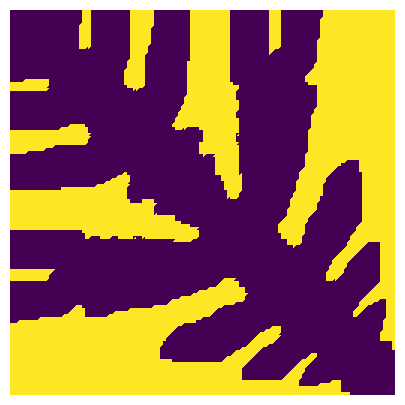

In [20]:
admmcolin.plot_control(disc=True)

In [21]:
admmcolin.trial(0).series.compliance_disc[-1]

1.4995807923394624

In [57]:
64 * admmcolin.tv / admmcolin.alpha

902.9554108468294

In [58]:
admmcolin.compliance

3.8705695992998885

In [47]:
import h5py

with h5py.File("run_data_admm_gurobi_mip/0.01/64.h5", "r") as f:
    f.visititems(lambda name, obj: print(name, obj.shape if hasattr(obj, "shape") else "Group"))

seed_0 Group
seed_0/compliance_disc_list (20,)
seed_0/compliance_list (21,)
seed_0/infeas_list (21,)
seed_0/iters Group
seed_0/iters/a_disc_list (21, 8192)
seed_0/iters/a_list (21, 8192)
seed_0/iters/b_list (21, 8192)
seed_0/iters/lambda_list (21, 8192)
seed_0/iters/u_list (21, 4225)
seed_0/objective_disc_list (20,)
seed_0/objective_list (21,)
seed_0/rho_list (20,)
seed_0/runtime_sub1_list (20,)
seed_0/runtime_sub2_list (20,)
seed_0/tv_disc_list (20,)
seed_0/tv_list (21,)
summary Group
summary/best_compliance ()
summary/best_iters Group
summary/best_iters/a_disc_list (21, 8192)
summary/best_iters/a_list (21, 8192)
summary/best_iters/b_list (21, 8192)
summary/best_iters/lambda_list (21, 8192)
summary/best_iters/u_list (21, 4225)
summary/best_objective ()
summary/best_seed_name ()
summary/best_tv ()
summary/median_compliance ()
summary/median_iters Group
summary/median_iters/a_disc_list (21, 8192)
summary/median_iters/a_list (21, 8192)
summary/median_iters/b_list (21, 8192)
summary/media

In [44]:
c1 = admmcolin.trial(0).iters.control_1[9]
c2 = admmcolin.trial(0).iters.control_2[9]

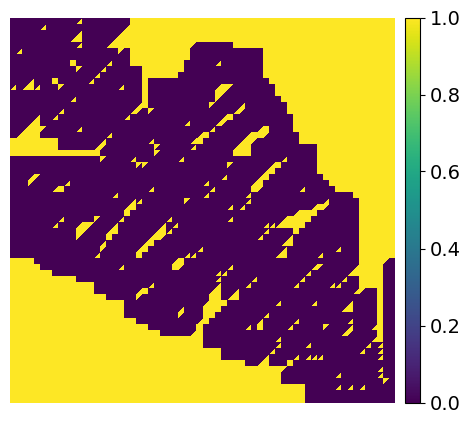

In [45]:
admmcolin.plot_control(c2)

Please enter a valid value for 'which' \in {1, 2}


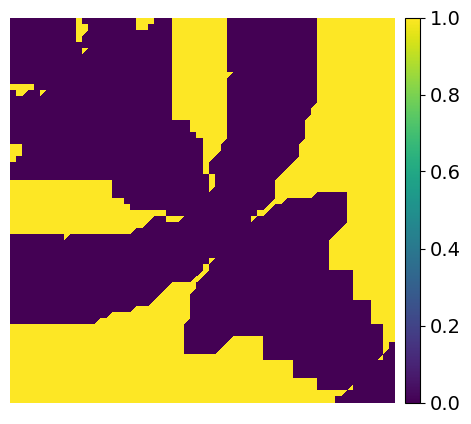

In [61]:
admmcolin.plot_control(disc=True)

In [46]:
import networkx as nx
import math

def build_graph(n_x: int, n_y: int):
    """Graph builder from the provided TV reference."""
    N = n_x * n_y
    graph = nx.Graph()
    graph.add_nodes_from(range(N))

    for k in range(0, N, 2):
        if k + 1 < N:
            graph.add_edge(k, k + 1)
        if (k + 2) % n_y != 0 and k + 3 < N:
            graph.add_edge(k, k + 3)
        if (k // n_y) != 0:
            nb = k - (n_y - 1)
            if nb >= 0:
                graph.add_edge(k, nb)

    return graph


def build_scale(graph: nx.Graph):
    scale = np.zeros(len(graph.edges()), dtype=float)
    for k, (u, v) in enumerate(graph.edges()):
        scale[k] = math.sqrt(2.0) if abs(int(u) - int(v)) == 1 else 1.0
    return scale


def compute_tv(control: np.ndarray, graph: nx.Graph, scale: np.ndarray) -> float:
    diffs = []
    for (u, v), s in zip(graph.edges(), scale):
        diffs.append(s * abs(control[u] - control[v]))
    return float(sum(diffs))


graph = build_graph(64, 2*64)
scale = build_scale(graph)
tv = compute_tv(admmcolin.trial(0).iters.control_disc[-1], graph, scale)
print(tv)

902.9554108468293


In [24]:
import networkx as nx
import math

def build_graph(n_x: int, n_y: int):
    """Graph builder from the provided TV reference."""
    N = n_x * n_y
    graph = nx.Graph()
    graph.add_nodes_from(range(N))

    for k in range(0, N, 2):
        if k + 1 < N:
            graph.add_edge(k, k + 1)
        if (k + 2) % n_y != 0 and k + 3 < N:
            graph.add_edge(k, k + 3)
        if (k // n_y) != 0:
            nb = k - (n_y - 1)
            if nb >= 0:
                graph.add_edge(k, nb)

    return graph


def build_scale(graph: nx.Graph):
    scale = np.zeros(len(graph.edges()), dtype=float)
    for k, (u, v) in enumerate(graph.edges()):
        scale[k] = math.sqrt(2.0) if abs(int(u) - int(v)) == 1 else 1.0
    return scale


def compute_tv(control: np.ndarray, graph: nx.Graph, scale: np.ndarray) -> float:
    diffs = []
    for (u, v), s in zip(graph.edges(), scale):
        diffs.append(s * abs(control[u] - control[v]))
    return float(sum(diffs))


graph = build_graph(64, 2*64)
scale = build_scale(graph)
tv = compute_tv(admmcolin.trial(0).iters.control_disc[-1], graph, scale)
print(tv)

618.8772003600261


In [ ]:
print("total subproblem 1 runtime:",admmcolin.trial(0).series.runtime_sub1.sum())
print("total subproblem 2 runtime:",admmcolin.trial(0).series.runtime_sub2.sum())

total subproblem 1 runtime: 1.8436723269987851
total subproblem 2 runtime: 9.627769120037556


In [ ]:
admmcolin.trial(0).describe_tree()

### Here is an example on how to access the data in series group 

In [18]:
admmcolin.trial(0).series.objective_disc
#admmcolin.trial(0).series.infeas

array([11.60191742, 10.75944402, 11.12596075, 10.8487884 , 10.62099531,
        8.62109944,  8.56299446,  6.65752719,  4.3366999 ,  4.00007819,
        4.06634392,  4.07776485,  3.61896635,  3.43426848,  3.25956687,
        3.16072406,  3.13414339,  2.90033833,  2.63427518,  2.41724712])

### Here is an example on how to access the data in iters group (5th control and state iterate)

In [30]:
admmcolin.trial(0).series.tv_disc
#admmcolin.trial(0).series.infeas

array([139.65685425, 146.        , 154.        , 161.65685425,
       164.        , 171.65685425, 152.        , 167.3137085 ,
       159.65685425, 179.79898987, 186.14213562, 187.97056275,
       177.14213562, 185.11269837, 198.11269837, 188.79898987,
       192.79898987, 204.28427125, 210.79898987, 210.45584412])

In [59]:
control_2 = admmcolin.trial(0).iters.control_2[15]
control_1 = admmcolin.trial(0).iters.control_1[15]
control_disc = admmcolin.trial(0).iters.control_disc[15]
state_1 = admmcolin.trial(0).iters.state[15]

###  For randomized solver we store the median and best control, objective etc separately

In [ ]:
admmcolin.objective   #median
admmcolin.objective_best #best

## Same for control
admmcolin.control   #median
admmcolin.control_best #best

### Plot the best and median control across runs

Please enter a valid value for 'which' \in {1, 2}


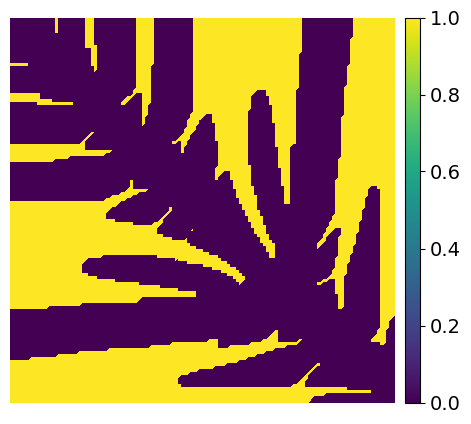

In [48]:
admmcolin.plot_control(disc=True) #median

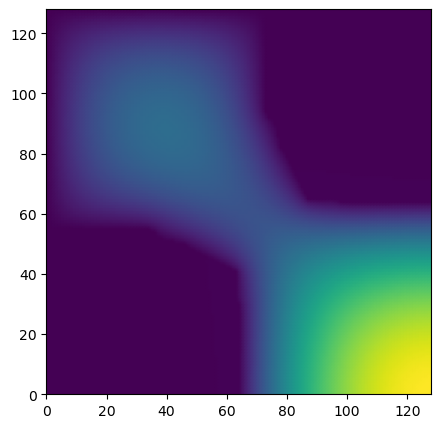

/home/harsh/topo_opt_git/admm_methods/admm_colin/admmcolinviz.py:162: UserWarning: Adding colorbar to a different Figure <Figure size 600x500 with 2 Axes> than <Figure size 640x480 with 0 Axes> which fig.colorbar is called on.
  cbar = plt.colorbar(im, cax=cax, shrink=0.85)


<Figure size 640x480 with 0 Axes>

In [61]:
admmcolin.plot_state()

### To plot a specific iterate, you can pass it as an argument

In [ ]:
fig,ax = plt.subplots(figsize=(6,6), nrows=1, ncols=2)

c5 = admmcolin.trial(0).iters.control[5]
s5 = admmcolin.trial(0).iters.state[5]
admmcolin.plot_control(c5, ax=ax[0])
admmcolin.plot_state(s5, ax=ax[1])

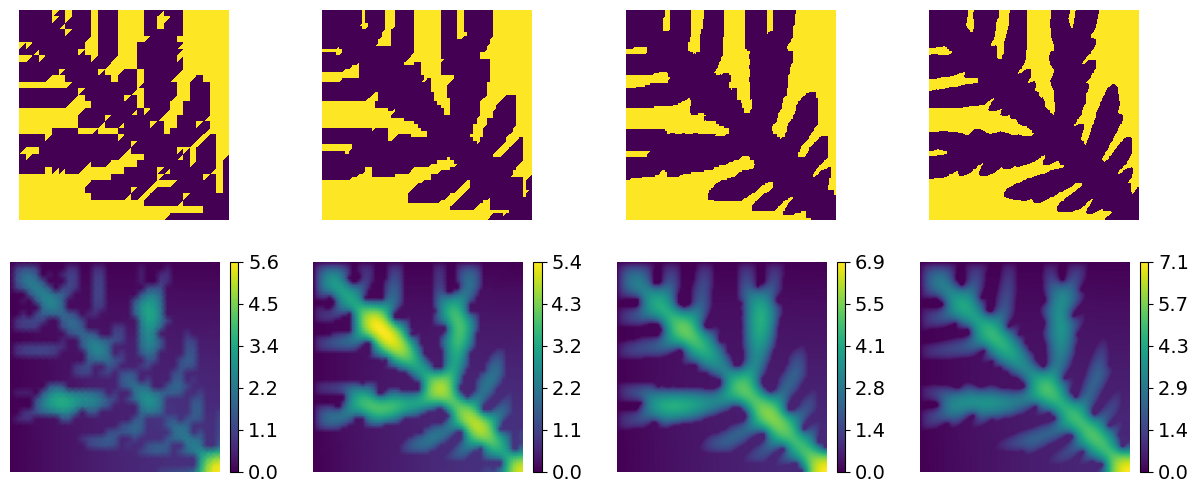

In [2]:
mesh_list = [32,64,128,256]
fig,ax = plt.subplots(figsize=(15,6), nrows=2, ncols=4)
for i, mesh in enumerate(mesh_list):
    admmcolin = ADMMColin(alpha=0.015, dim=mesh, base_dir="run_data_admm_osqp")
    c = admmcolin.trial(0).iters.control_disc[-1]
    s = admmcolin.trial(0).iters.state[-1]
    admmcolin.plot_control(c, ax=ax[0][i], show=False, title="")
    admmcolin.plot_state(s, ax=ax[1][i], show=False, title="")

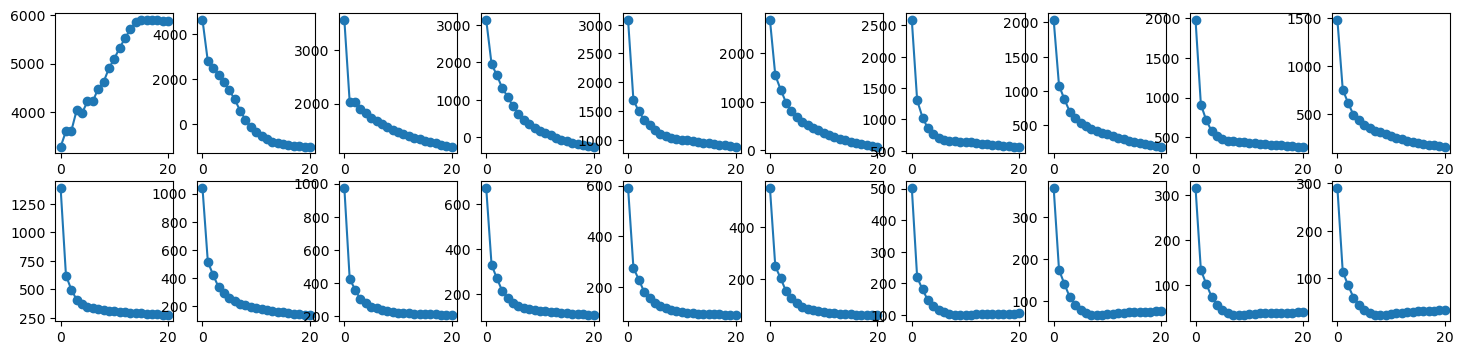

In [17]:
admmcolin = ADMMColin(alpha=0.01, dim=64, base_dir="run_data_admm_running_avg_gurobi")
fig,ax = plt.subplots(figsize=(18,4), nrows=2, ncols=10)

for i in range(20):
    f_i = admmcolin.trial(0).iters.oc_iters.F[i]
    ax[i//10][i%10].plot(f_i, label=f"iter {i}")
    ax[i//10][i%10].scatter(range(len(f_i)), f_i, label=f"iter {i}")

In [9]:
# Example calls (uncomment one):
#run_admm_animation(mesh_dim=32, folder="run_data_admm_running_avg_gurobi", alpha=0.01, seed=0)
run_admm_animation(mesh_dim=32, folder="run_data_admm_periodic_gurobi", alpha=0.01, seed=0)


Saved GIF: admm_anim_run_data_admm_periodic_gurobi_alpha_0.01_dim_32_seed_0.gif


'admm_anim_run_data_admm_periodic_gurobi_alpha_0.01_dim_32_seed_0.gif'

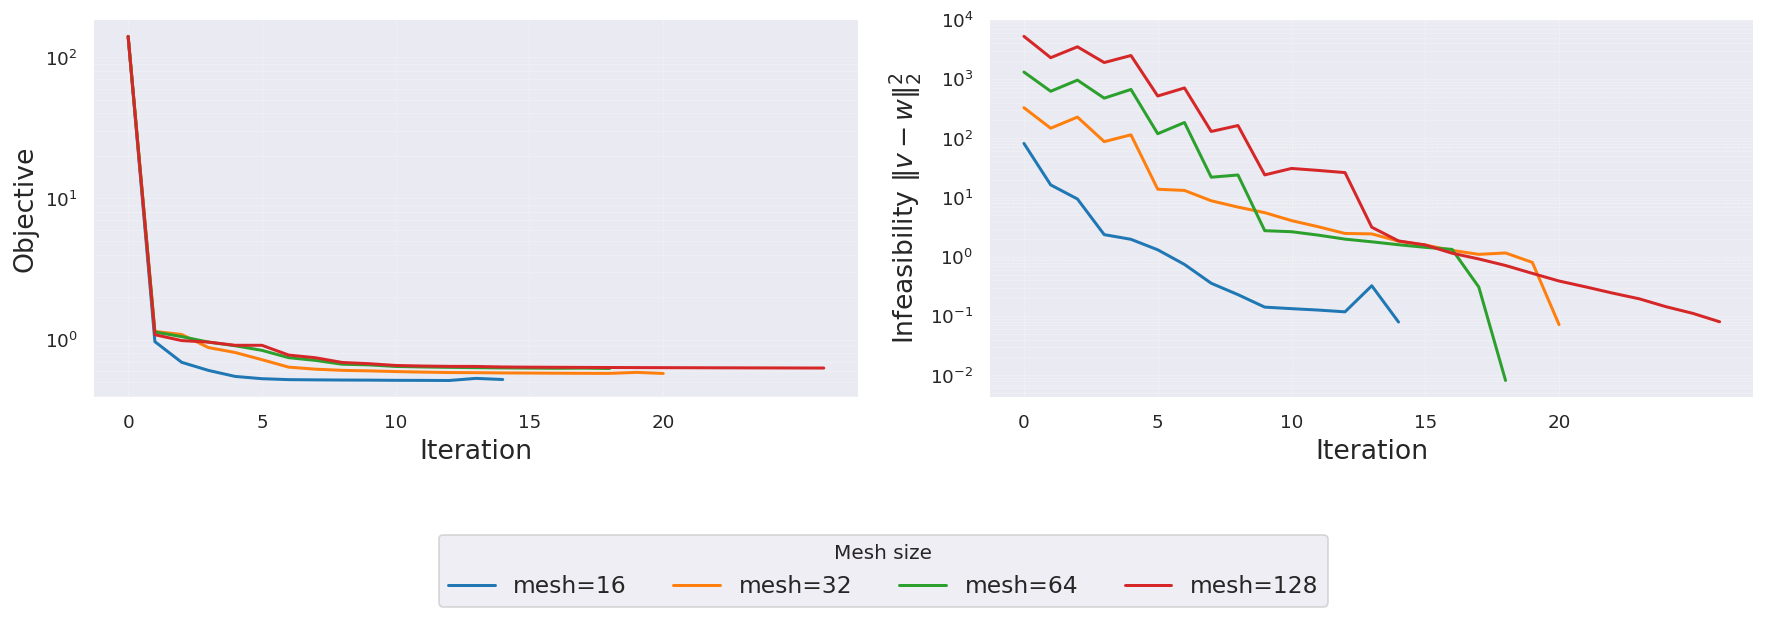

In [7]:
# Objective + infeasibility trajectories across mesh sizes (side-by-side)
mesh_sizes = [16, 32, 64, 128]
#base_dir = "run_data_admm_gurobi_great"
base_dir = "run_data_admm_running_avg_gurobi"
alpha = 0.01
seed = 0

# --- nicer plotting style (seaborn optional) ---
import matplotlib as mpl

base_rc = {
    "figure.dpi": 120,
    "lines.linewidth": 2.8,
    "lines.markersize": 5,
    "font.size": 16,
    "axes.labelsize": 16,
    "axes.titlesize": 18,
    "legend.fontsize": 14,
}

try:
    import seaborn as sns
    sns.set_theme(style="darkgrid")
    mpl.rcParams.update(base_rc)
except Exception:
    mpl.rcParams.update(base_rc)


# Use tab10 colorblind-friendly palette
cmap = plt.get_cmap("tab10")
colors = [cmap(i % cmap.N) for i in range(len(mesh_sizes))]


fig, ax = plt.subplots(1, 2, figsize=(15, 5))

for mesh, color in zip(mesh_sizes, colors):
    trial_series = ADMMColin(alpha=alpha, dim=mesh, base_dir=base_dir).trial(seed).series
    objective = np.asarray(trial_series.objective, dtype=float)
    infeas = np.asarray(trial_series.infeas, dtype=float)

    ax[0].plot(
        np.arange(len(objective)),
        objective,
        color=color,
        linewidth=1.8,
        label=f"mesh={mesh}",
        alpha=1.0,
    )

    ax[1].plot(
        np.arange(len(infeas)),
        infeas,
        color=color,
        linewidth=1.8,
        label=f"mesh={mesh}",
        alpha=1.0,
    )


# Objective plot
# ax[0].set_title("Objective Trajectories")
ax[0].set_xlabel("Iteration")
ax[0].set_ylabel("Objective")
ax[0].set_yscale("log")
ax[0].set_xticks([0, 5, 10, 15, 20])
ax[0].grid(
    True,
    which="both",
    linestyle="--",
    linewidth=0.3,
    alpha=0.6,
)

# Infeasibility plot
# ax[1].set_title("Infeasibility Trajectories")
ax[1].set_xlabel("Iteration")
ax[1].set_ylabel(r"Infeasibility $\|v-w\|_2^2$")
ax[1].set_yscale("log")
ax[1].set_xticks([0, 5, 10, 15, 20])
ax[1].grid(
    True,
    which="both",
    linestyle="--",
    linewidth=0.3,
    alpha=0.6,
)


# One shared legend below both plots
handles, labels = ax[0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    title="Mesh size",
    loc="upper center",
    bbox_to_anchor=(0.5, 0.1),
    ncol=len(mesh_sizes),
    frameon=True,
)

plt.tight_layout(rect=(0, 0.15, 1, 1))
plt.show()

In [7]:
admmcolin = ADMMColin(alpha=0.01, dim=128, base_dir="run_data_admm_running_avg_gurobi")
runtime1 = admmcolin.trial(0).series.runtime_sub1.sum()
runtime2 = admmcolin.trial(0).series.runtime_sub2.sum()
print(f"Total subproblem 1 runtime: {runtime1:.2f} seconds")
print(f"Total subproblem 2 runtime: {runtime2:.2f} seconds")
print(f"Total runtime: {runtime1 + runtime2:.2f} seconds")

Total subproblem 1 runtime: 314.24 seconds
Total subproblem 2 runtime: 2855.86 seconds
Total runtime: 3170.10 seconds


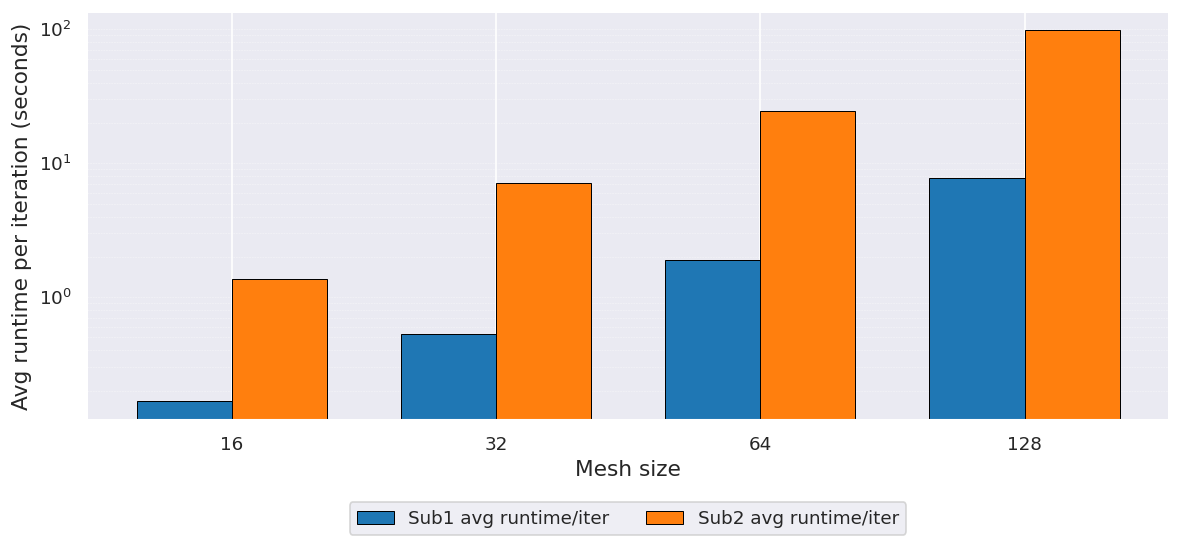

mesh= 16 | sub1=1.672e-01 s/iter | sub2=1.358e+00 s/iter
mesh= 32 | sub1=5.309e-01 s/iter | sub2=7.060e+00 s/iter
mesh= 64 | sub1=1.883e+00 s/iter | sub2=2.442e+01 s/iter
mesh=128 | sub1=7.720e+00 s/iter | sub2=9.798e+01 s/iter


In [8]:
# Runtime comparison across mesh sizes: average per-iteration subproblem runtime
mesh_sizes = [16, 32, 64, 128]
base_dir = "run_data_admm_running_avg_gurobi"
alpha = 0.01
seed = 0

avg_sub1 = []
avg_sub2 = []

for mesh in mesh_sizes:
    trial_series = ADMMColin(alpha=alpha, dim=mesh, base_dir=base_dir).trial(seed).series
    runtime_sub1 = np.asarray(trial_series.runtime_sub1, dtype=float)
    runtime_sub2 = np.asarray(trial_series.runtime_sub2, dtype=float)

    avg_sub1.append(runtime_sub1.mean() if runtime_sub1.size > 0 else np.nan)
    avg_sub2.append(runtime_sub2.mean() if runtime_sub2.size > 0 else np.nan)


# --- nicer plotting style (seaborn optional) ---
import matplotlib as mpl

base_rc = {
    "figure.dpi": 120,
    "lines.linewidth": 2.8,
    "lines.markersize": 5,
    "font.size": 12,
    "axes.labelsize": 13,
    "axes.titlesize": 14,
    "legend.fontsize": 11,
}

try:
    import seaborn as sns
    sns.set_theme(style="darkgrid")
    mpl.rcParams.update(base_rc)
except Exception:
    mpl.rcParams.update(base_rc)


# Use tab10 colorblind-friendly palette
cmap = plt.get_cmap("tab10")
colors = [cmap(i) for i in range(2)]


x = np.arange(len(mesh_sizes))
width = 0.36

fig, ax = plt.subplots(figsize=(10, 5))

ax.bar(
    x - width / 2,
    avg_sub1,
    width=width,
    color=colors[0],
    edgecolor="black",
    linewidth=0.6,
    label="Sub1 avg runtime/iter",
)

ax.bar(
    x + width / 2,
    avg_sub2,
    width=width,
    color=colors[1],
    edgecolor="black",
    linewidth=0.6,
    label="Sub2 avg runtime/iter",
)

ax.set_xticks(x)
ax.set_xticklabels([str(m) for m in mesh_sizes])
ax.set_xlabel("Mesh size")
ax.set_ylabel("Avg runtime per iteration (seconds)")
# ax.set_title("Per-Iteration Runtime by Mesh Size")

ax.set_yscale("log")

ax.grid(
    True,
    axis="y",
    which="both",
    linestyle="--",
    linewidth=0.3,
    alpha=0.6,
)

# Legend below plot, same style as your second example
ax.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, -0.18),
    ncol=2,
    frameon=True,
)

plt.tight_layout(rect=(0, 0.04, 1, 1))
plt.show()


for mesh, r1, r2 in zip(mesh_sizes, avg_sub1, avg_sub2):
    print(f"mesh={mesh:>3} | sub1={r1:.3e} s/iter | sub2={r2:.3e} s/iter")

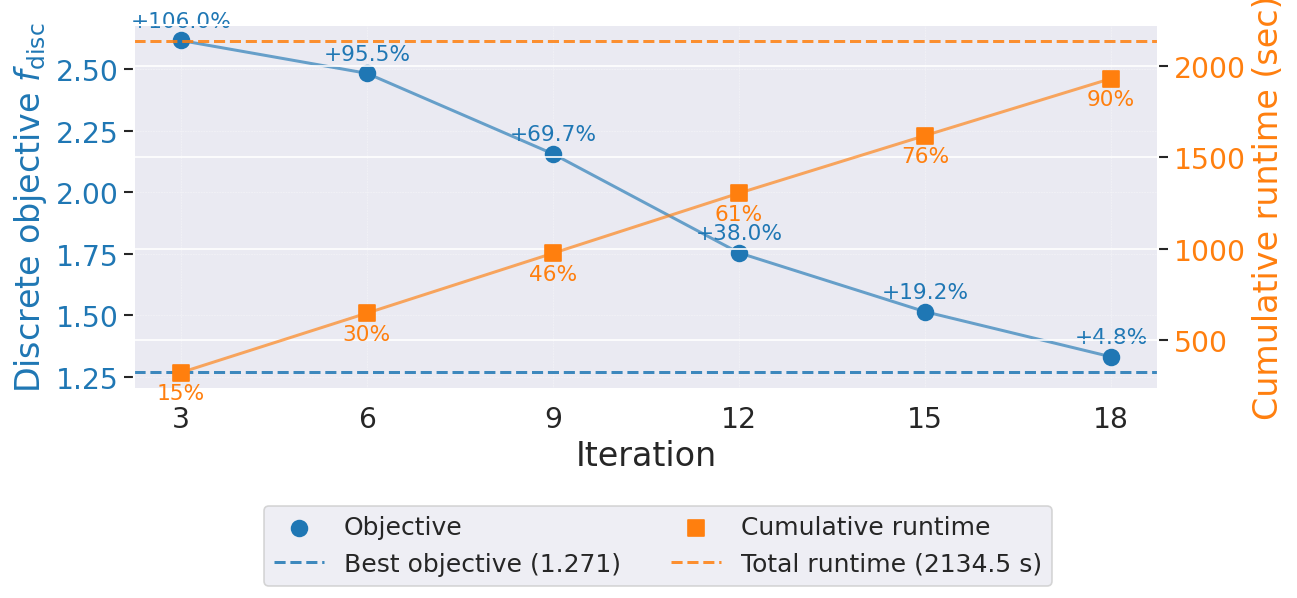

In [13]:
# Convergence vs. runtime tradeoff: objective_disc & cumulative runtime at every 3 iterations
dim = 128
objective_dir = "run_data_admm_gurobi_great"
runtime_dir   = "run_data_admm_running_avg_gurobi"
alpha = 0.01
seed = 0
step = 3

# --- nicer plotting style (seaborn optional) ---
import matplotlib as mpl

base_rc = {
    "figure.dpi": 120,

    # line style
    "lines.linewidth": 2.8,
    "lines.markersize": 6,

    # global font sizes
    "font.size": 18,
    "axes.labelsize": 20,
    "axes.titlesize": 20,
    "xtick.labelsize": 17,
    "ytick.labelsize": 17,
    "legend.fontsize": 15,
    "legend.title_fontsize": 16,
}

try:
    import seaborn as sns
    sns.set_theme(style="darkgrid")
    mpl.rcParams.update(base_rc)
except Exception:
    mpl.rcParams.update(base_rc)


trial_obj = ADMMColin(alpha=alpha, dim=dim, base_dir=objective_dir).trial(seed)
trial_rt  = ADMMColin(alpha=alpha, dim=dim, base_dir=runtime_dir).trial(seed)

obj_disc = np.asarray(trial_obj.series.objective_disc, dtype=float)
rt_sub1  = np.asarray(trial_rt.series.runtime_sub1, dtype=float)
rt_sub2  = np.asarray(trial_rt.series.runtime_sub2, dtype=float)

# cumulative total runtime at each completed iteration
n_iters_rt = min(len(rt_sub1), len(rt_sub2))
cum_runtime = np.cumsum(rt_sub1[:n_iters_rt] + rt_sub2[:n_iters_rt])

# align obj_disc: if it carries an extra initial entry at index 0, drop it
n_iters_obj = len(obj_disc)
if n_iters_obj == n_iters_rt + 1:
    obj_disc = obj_disc[1:]

n_iters = min(len(obj_disc), n_iters_rt)
obj_disc = obj_disc[:n_iters]
cum_runtime = cum_runtime[:n_iters]

# reference values for the dashed lines
max_runtime = cum_runtime[-1]
best_obj_disc = np.nanmin(obj_disc)

# select every step-th iteration
tick_iters = np.arange(step - 1, n_iters, step)

# Use tab10 colorblind-friendly palette
cmap = plt.get_cmap("tab10")
color_obj = cmap(0)
color_rt = cmap(1)


fig, ax1 = plt.subplots(figsize=(11, 5))
ax2 = ax1.twinx()

sc1 = ax1.scatter(
    tick_iters + 1,
    obj_disc[tick_iters],
    marker="o",
    s=90,
    color=color_obj,
    zorder=3,
    label="Objective",
)

ln1 = ax1.plot(
    tick_iters + 1,
    obj_disc[tick_iters],
    color=color_obj,
    linewidth=1.8,
    alpha=0.65,
    zorder=2,
)

sc2 = ax2.scatter(
    tick_iters + 1,
    cum_runtime[tick_iters],
    marker="s",
    s=90,
    color=color_rt,
    zorder=3,
    label="Cumulative runtime",
)

ln2 = ax2.plot(
    tick_iters + 1,
    cum_runtime[tick_iters],
    color=color_rt,
    linewidth=1.8,
    alpha=0.65,
    zorder=2,
)


# --- annotations ---
for idx in tick_iters:
    pct_obj = (obj_disc[idx] - best_obj_disc) / abs(best_obj_disc) * 100
    pct_rt = cum_runtime[idx] / max_runtime * 100

    ax1.annotate(
        f"+{pct_obj:.1f}%",
        xy=(idx + 1, obj_disc[idx]),
        xytext=(0, 8),
        textcoords="offset points",
        ha="center",
        fontsize=13,
        color=color_obj,
    )

    ax2.annotate(
        f"{pct_rt:.0f}%",
        xy=(idx + 1, cum_runtime[idx]),
        xytext=(0, -16),
        textcoords="offset points",
        ha="center",
        fontsize=13,
        color=color_rt,
    )


# --- reference dashed lines ---
hl_rt = ax2.axhline(
    max_runtime,
    color=color_rt,
    linewidth=1.8,
    linestyle="--",
    alpha=0.85,
    label=f"Total runtime ({max_runtime:.1f} s)",
)

hl_obj = ax1.axhline(
    best_obj_disc,
    color=color_obj,
    linewidth=1.8,
    linestyle="--",
    alpha=0.85,
    label=f"Best objective ({best_obj_disc:.4g})",
)


ax1.set_xlabel("Iteration")
ax1.set_ylabel(r"Discrete objective $f_{\rm disc}$", color=color_obj)
ax2.set_ylabel("Cumulative runtime (sec)", color=color_rt)

ax1.tick_params(axis="y", labelcolor=color_obj)
ax2.tick_params(axis="y", labelcolor=color_rt)

ax1.set_xticks(tick_iters + 1)
ax1.set_ylim(bottom=1.2)

ax1.grid(
    True,
    which="both",
    linestyle="--",
    linewidth=0.3,
    alpha=0.6,
)

# Optional title; comment out if you want the clean paper-style look
# fig.suptitle(
#     f"Convergence vs. Runtime Tradeoff  |  dim={dim}, alpha={alpha}",
#     fontsize=20,
# )


handles = [sc1, hl_obj, sc2, hl_rt]
labels = [h.get_label() for h in handles]

fig.legend(
    handles,
    labels,
    loc="upper center",
    bbox_to_anchor=(0.5, 0.15),
    ncol=2,
    frameon=True,
)

plt.tight_layout(rect=(0, 0.13, 1, 1))
plt.show()

### OSQP tests

In [1]:
from admmcolinviz import ADMMColin
from subproblem2_solver import Subproblem2Solver
import numpy as np

/home/harsh/anaconda3/envs/fenics_work/lib/python3.11/site-packages/ufl/__init__.py:250: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


In [2]:
n = 64
alpha = 0.0134
seed = 0
admmcolin = ADMMColin(alpha=alpha, dim=n, base_dir="run_data_admm_gurobi")
rho = admmcolin.trial(0).meta["rho_init"]

In [7]:
b = admmcolin.trial(0).iters.control_1[9]
a = admmcolin.trial(0).iters.control_2[8]
lam = admmcolin.trial(0).iters.lam[8]

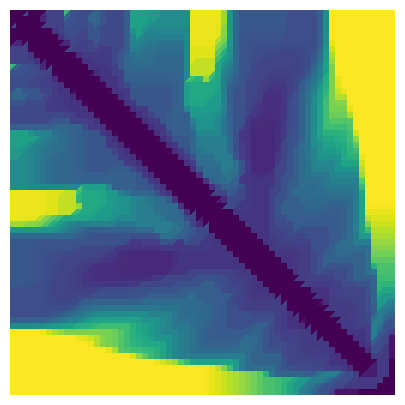

In [8]:
admmcolin.plot_control(a)

In [ ]:
sub2 = Subproblem2Solver(n, 2*n, alpha, seed, use_mip=False, cutoff_time=None)
a, status = sub2.run(a, b, lam, rho=rho, V_max=0.4, seed = seed, k=7, backend="osqp")

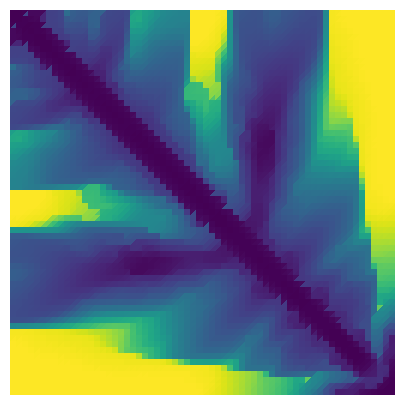

In [10]:
admmcolin.plot_control(a)

### Actual OSQP

In [18]:
n = 64
alpha = 0.01
seed = 0
admmcolin = ADMMColin(alpha=alpha, dim=n, base_dir="run_data_admm_osqp")
rho = admmcolin.trial(0).meta["rho_init"]

In [ ]:
admmcolin.trial(0).series.infeas

0.8031709407823266

Please enter a valid value for 'which' \in {1, 2}


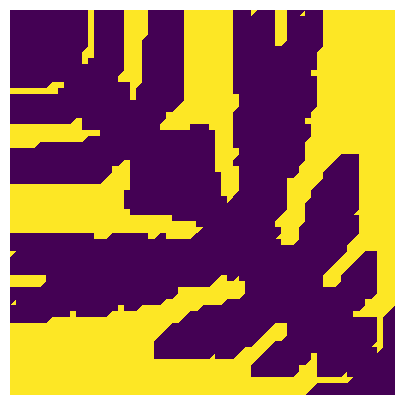

In [16]:
admmcolin.plot_control(disc=True)

In [29]:
import networkx as nx

G = nx.Graph()
G.add_node(0)
G.add_node(1)
G.add_node(2)
G.add_node(3)
G.add_edge(0, 1)
G.add_edge(0, 2)
G.add_edge(1, 3)

In [32]:
B = []
row = []
col = []
data = []
for i, (u, v) in enumerate(G.edges()):
    B.append([0 for _ in range(len(G.nodes()))])
    B[i][u] = 1
    B[i][v] = -1
    row.append(i)
    col.append(u)
    data.append(1)
    row.append(i)
    col.append(v)
    data.append(-1)

print(B)

[[1, -1, 0, 0], [1, 0, -1, 0], [0, 1, 0, -1]]


In [33]:
print(row)
print(col)
print(data)

[0, 0, 1, 1, 2, 2]
[0, 1, 0, 2, 1, 3]
[1, -1, 1, -1, 1, -1]


In [3]:
import os

base_dir = "run_data_admm_gurobi_mip_old"

names = [d for d in os.listdir(base_dir)
         if os.path.isdir(os.path.join(base_dir, d))]

print(",".join(names))

0.0125,0.027,0.055,0.01,0.013,0.031,0.024,0.07,0.0185,0.043,0.032,0.014,0.036,0.037,0.0425,0.08,0.0135,0.028,0.09,0.042,0.015,0.02,0.012,0.0145,0.044,0.05,0.03,0.0155,0.038,0.04,0.025,0.0165,0.018,0.017,0.034,0.041,0.06,0.016,0.035,0.039,0.1,0.021,0.045,0.022,0.023,0.026,0.033
